In [ ]:
import zipfile

zip_path = "/content/online+retail.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os

os.listdir('/content/dataset')

['Online Retail.xlsx']

In [ ]:
df = pd.read_excel('/content/dataset/Online Retail.xlsx')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
# Remove null values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove negative quantity
df = df[df['Quantity'] > 0]

# Remove negative price
df = df[df['UnitPrice'] > 0]

print(df.shape)

(392692, 8)


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['Month'] = df['InvoiceDate'].dt.month

In [ ]:
df['Year'] = df['InvoiceDate'].dt.year

# **EDA (Exploratory Data Analysis)**

**Top Selling Products**

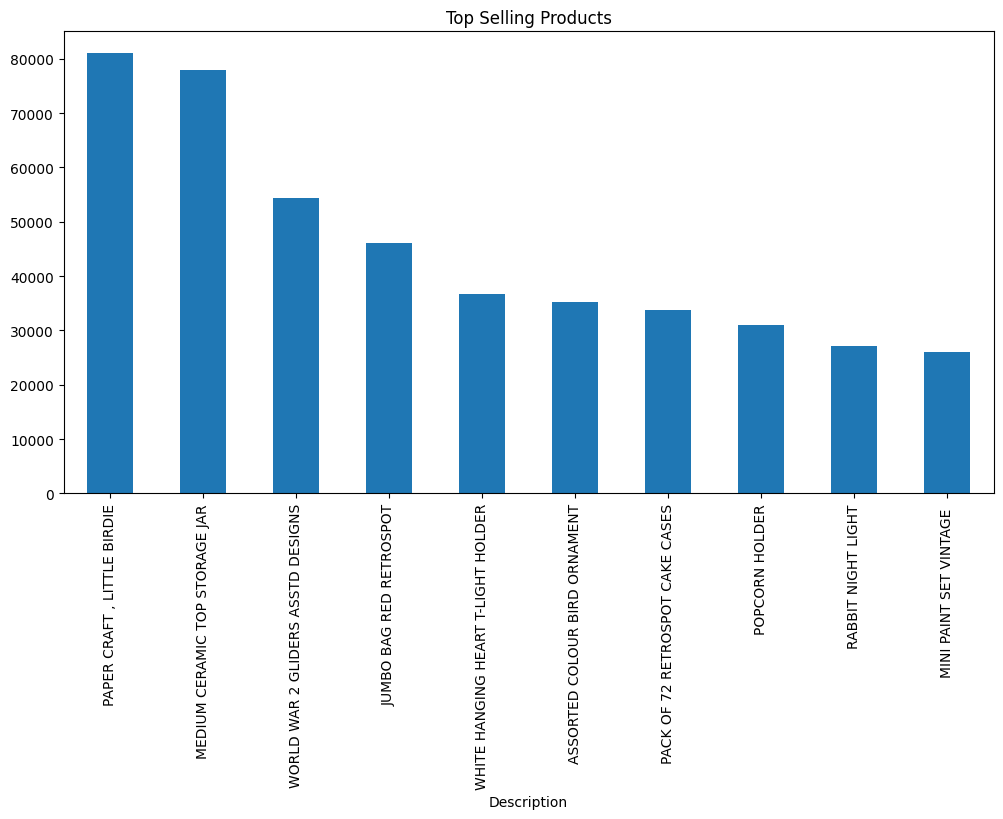

In [ ]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.show()

 Sales By Country

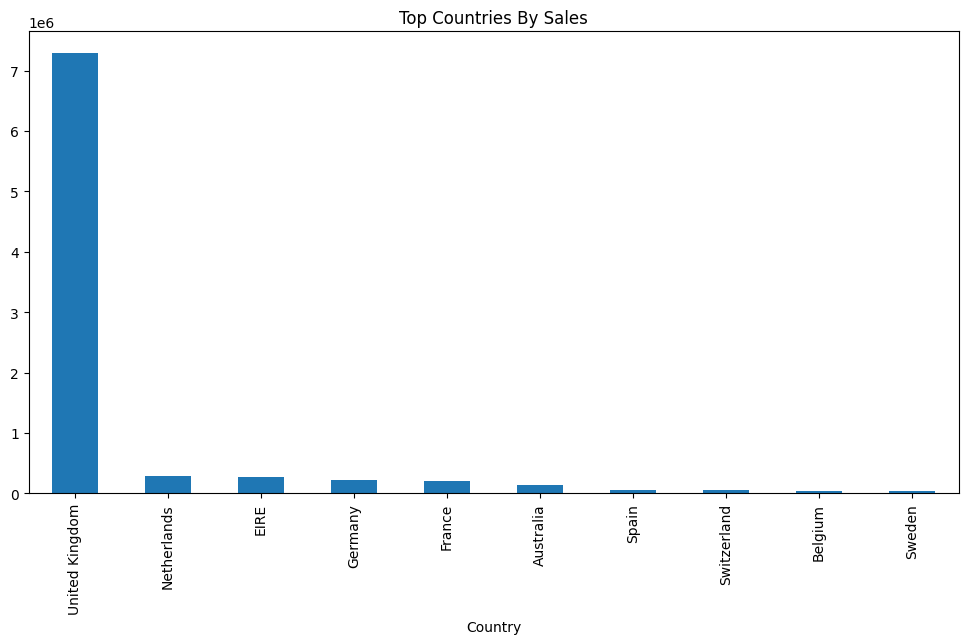

In [ ]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
country_sales.plot(kind='bar')
plt.title("Top Countries By Sales")
plt.show()

** Monthly Revenue**

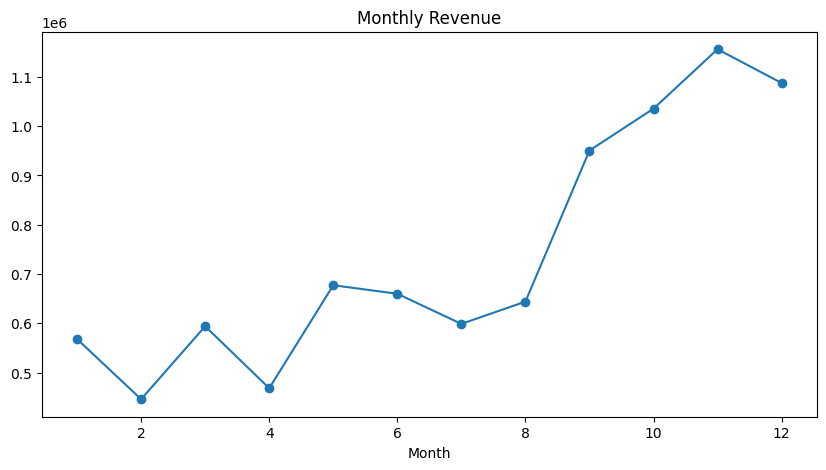

In [ ]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue")
plt.show()

# **CREATING RFM TABLE**

In [ ]:
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [ ]:
rfm.to_csv("rfm_analysis.csv", index=False)

In [ ]:
from google.colab import files

files.download("rfm_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Normalize Data**

In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

**[ Applying KMeans Clustering](https://)**

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,1
12347.0,1,182,4310.00,0
12348.0,74,31,1797.24,0
12349.0,18,73,1757.55,0
12350.0,309,17,334.40,2


 Visualize Customer Segments

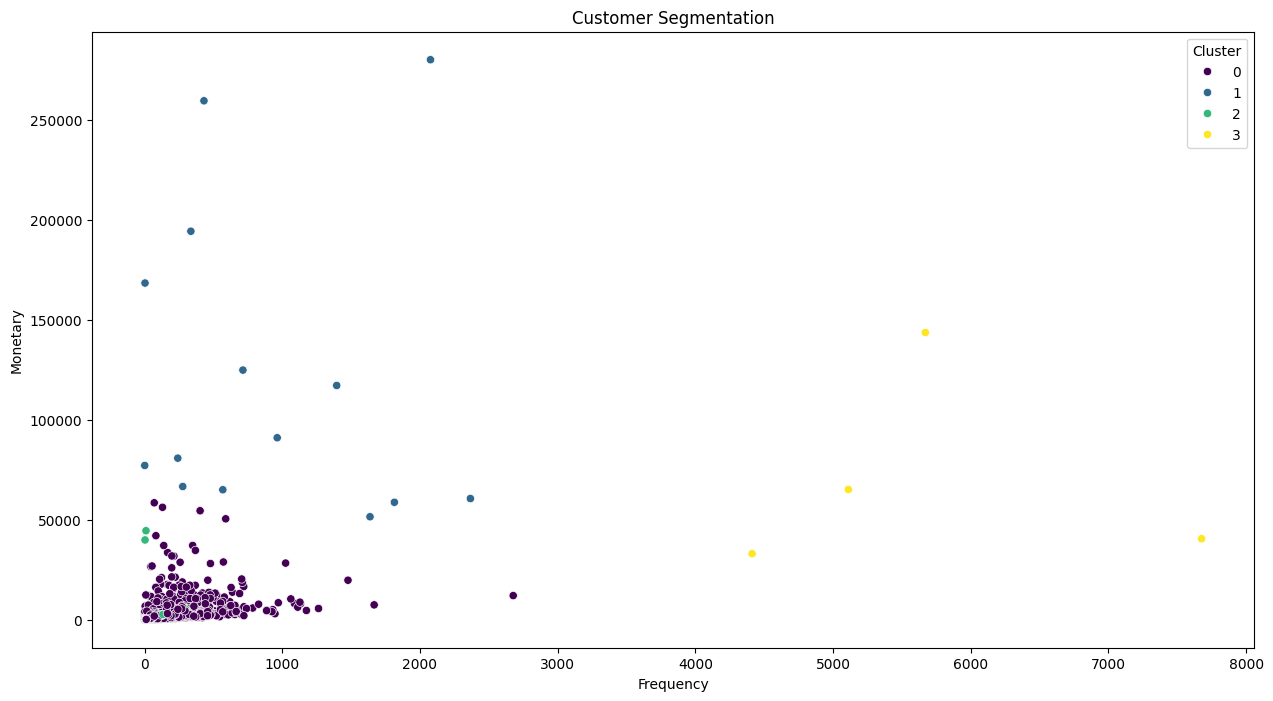

In [ ]:
plt.figure(figsize=(15,8))

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='viridis'
)

plt.title("Customer Segmentation")
plt.show()

# **` Demand Forecasting`**


**Preparing** data



In [ ]:
sales_forecast = df.groupby('InvoiceDate')['TotalPrice'].sum().reset_index()

sales_forecast.columns = ['ds', 'y']

**Training model**

In [ ]:
from prophet import Prophet

model = Prophet()

model.fit(sales_forecast)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


**Future prediction**

In [ ]:
future = model.make_future_dataframe(periods=10)

forecast = model.predict(future)

**Plot forecast**

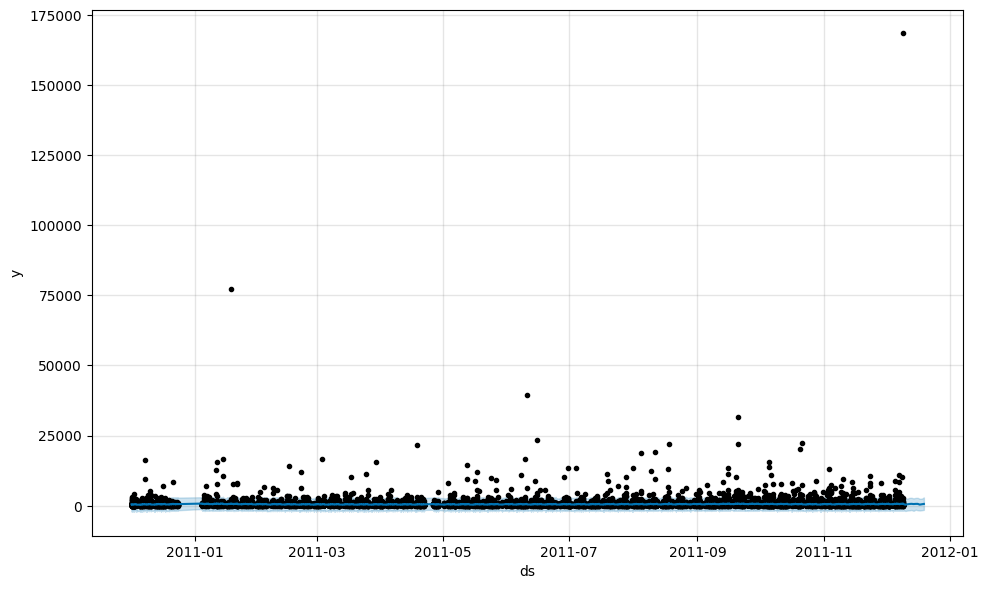

In [ ]:
model.plot(forecast)
plt.show()

In [ ]:
df.to_csv("cleaned_retail_data.csv", index=False)

In [ ]:
from google.colab import files

files.download("cleaned_retail_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Building Streamlit Dashboard**

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PAGE CONFIG
st.set_page_config(
    page_title="NeuralRetail Dashboard",
    layout="wide"
)

# TITLE
st.title("🛒 NeuralRetail Dashboard")
st.subheader("AI Powered Retail Analytics System")

# LOAD DATA
df = pd.read_csv("cleaned_retail_data.csv")

# SHOW DATA
st.write("### Dataset Preview")
st.dataframe(df.head())

# KPI SECTION
total_sales = df['TotalPrice'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()

col1, col2, col3 = st.columns(3)

col1.metric("Total Sales", f"${total_sales:,.2f}")
col2.metric("Total Orders", total_orders)
col3.metric("Total Customers", total_customers)

# TOP PRODUCTS
st.write("## Top Selling Products")

top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10,5))

top_products.plot(kind='bar', ax=ax)

plt.xticks(rotation=45)

st.pyplot(fig)

# SALES BY COUNTRY
st.write("## Sales By Country")

country_sales = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig2, ax2 = plt.subplots(figsize=(10,5))

country_sales.plot(kind='bar', ax=ax2)

plt.xticks(rotation=45)

st.pyplot(fig2)

2026-05-27 10:01:29.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 10:01:29.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 10:01:29.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 10:01:29.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 10:01:29.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 10:01:29.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 10:01:29.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 10:01:30.927 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

**STEP 1 — CREATE app.py FILE**

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="NeuralRetail Dashboard",
    layout="wide"
)

st.title("🛒 NeuralRetail Dashboard")
st.subheader("AI Powered Retail Analytics System")

# LOAD DATA
df = pd.read_csv("cleaned_retail_data.csv")

# SHOW DATA
st.write("## Dataset Preview")
st.dataframe(df.head())

# KPI
total_sales = df['TotalPrice'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()

col1, col2, col3 = st.columns(3)

col1.metric("Total Sales", f"${total_sales:,.2f}")
col2.metric("Total Orders", total_orders)
col3.metric("Total Customers", total_customers)

# TOP PRODUCTS
st.write("## Top Selling Products")

top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10,5))

top_products.plot(kind='bar', ax=ax)

plt.xticks(rotation=45)

st.pyplot(fig)

Writing app.py


**STEP 2 — SAVE CLEANED DATASET**

In [ ]:
df.to_csv("cleaned_retail_data.csv", index=False)

**STEP 3 — INSTALL STREAMLIT**

In [ ]:
!pip install streamlit pyngrok -q

**STEP 4 — RUN STREAMLIT**

In [ ]:
!streamlit run app.py &>/content/logs.txt &

**STEP 5 — CREATE PUBLIC LINK**

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦your url is: https://free-cobras-report.loca.lt
^C
